# Outliers

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

## Detection

### Charts

In [2]:
data = {'Age':[10,12,18,20,21,25,23,28,15,16,30,25,28,23,15,13,15,17,11,25,28,30,0.5,1,2,80,90,95]}
df = pd.DataFrame(data)
df

,Age
0,10.0
1,12.0
2,18.0
3,20.0
4,21.0
5,25.0
6,23.0
7,28.0
8,15.0
9,16.0


Pandas Box Plot

<Axes: >

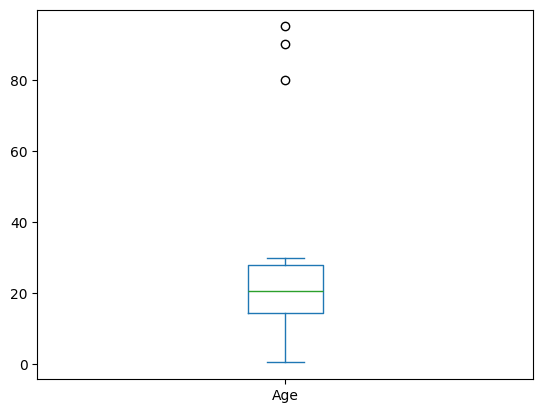

In [3]:
df['Age'].plot(kind='box')

Pandas Histogram

<Axes: ylabel='Frequency'>

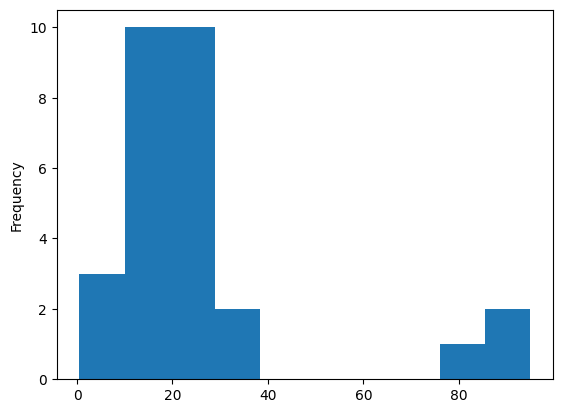

In [4]:
df['Age'].plot(kind='hist')

Pandas KDE plot

<Axes: ylabel='Density'>

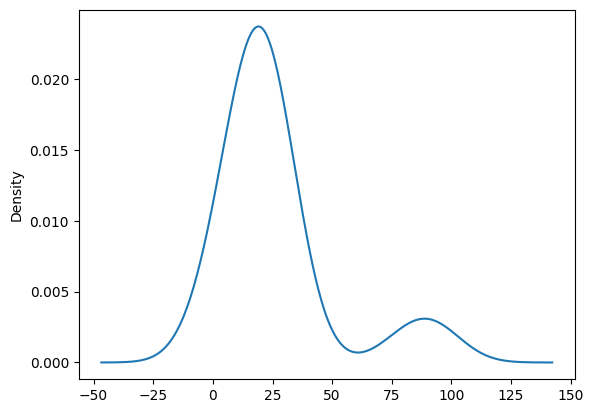

In [5]:
df['Age'].plot(kind='kde')

BoxPlot using Seaborn

<Axes: xlabel='Age'>

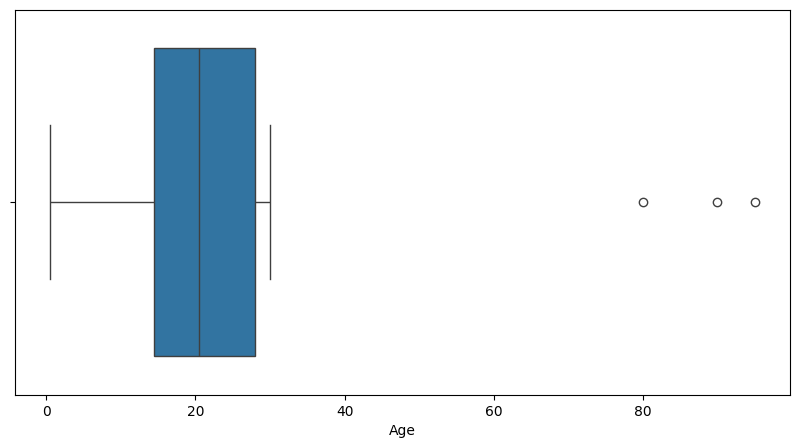

In [7]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Age')

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Age')
plt.show()

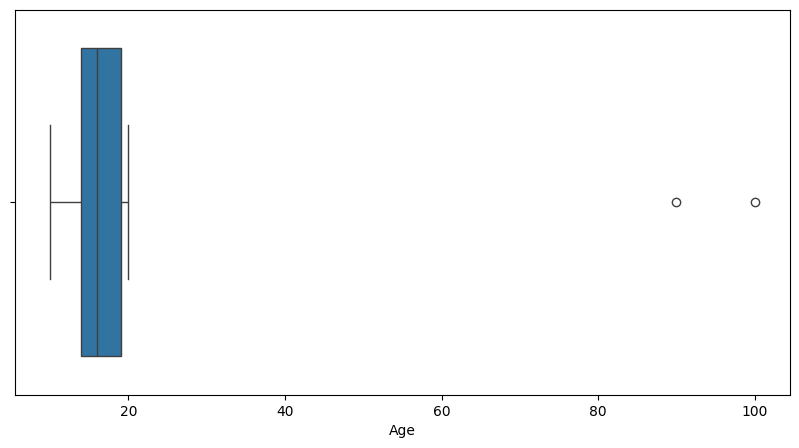

In [13]:
data = {'Age':[10,12,14,16,18,16,14,18,20,90,100]}
df = pd.DataFrame(data)
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Age')
plt.show()

Histogram using Seaborn

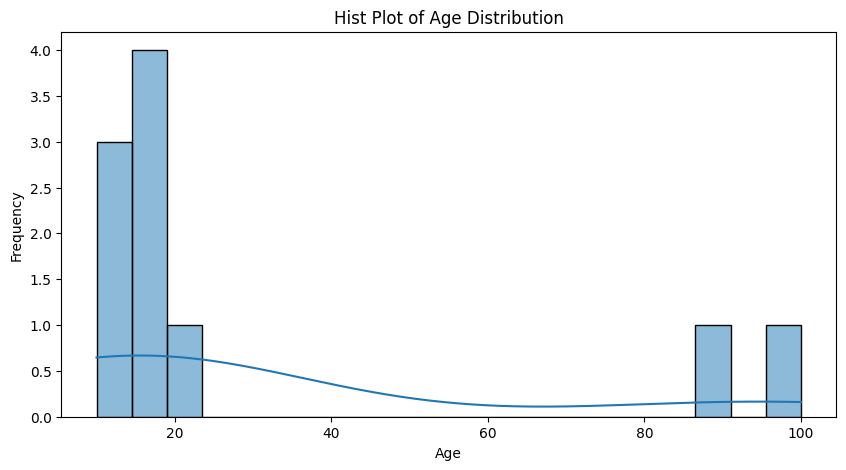

In [16]:
data = {'Age':[10,12,14,16,18,16,18,20,90,100]}
df = pd.DataFrame(data)
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='Age',kde=True)
plt.title("Hist Plot of Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Scatter Plot using Seaborn

In [17]:
data = {'Age':[10,12,14,16,18,16,18,20,60,65],
        'Salary':[3500,3800,4000,4200,4400,4200,4400,4500,8000,9000]}
df = pd.DataFrame(data)

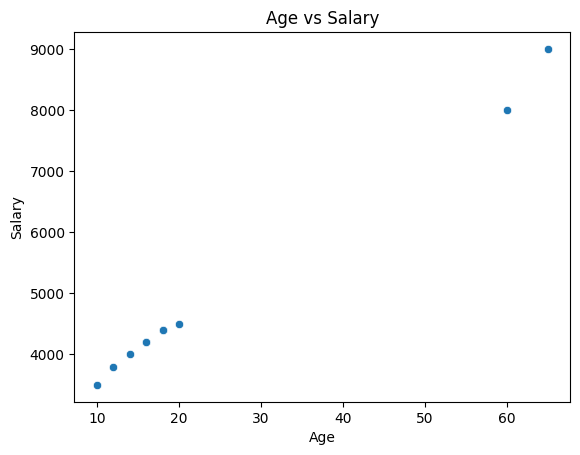

In [18]:
sns.scatterplot(data=df,x='Age',y='Salary')
plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

In [22]:
df1 = pd.read_csv("/content/diabetes.csv")

In [23]:
df1

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [24]:
df1.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


Text(0.5, 1.0, 'Age vs Preg')

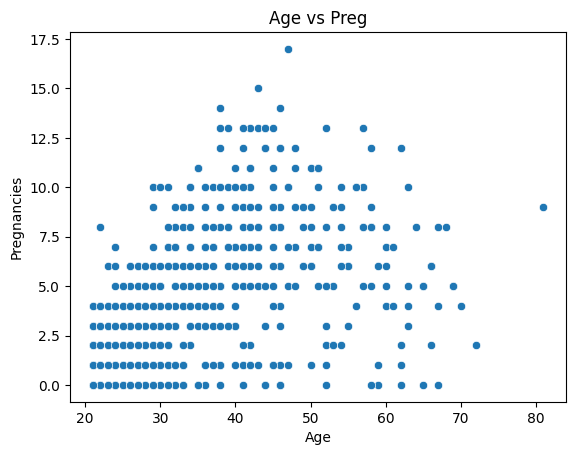

In [26]:
sns.scatterplot(data=df1,x='Age',y='Pregnancies')
plt.title("Age vs Preg")

Text(0.5, 1.0, 'Age vs BMI')

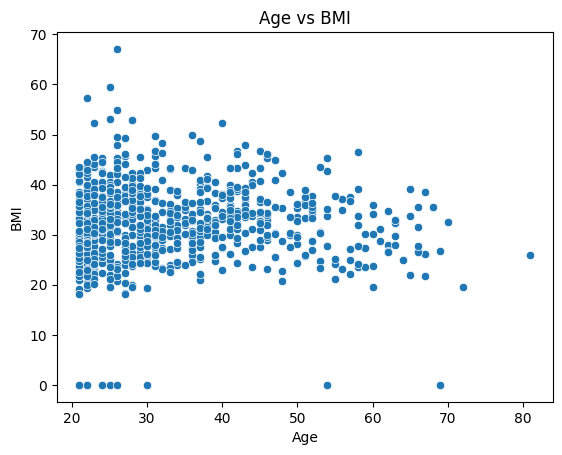

In [27]:
sns.scatterplot(data=df1,x='Age',y='BMI')
plt.title("Age vs BMI")

### Code

In [28]:
data = {'Age':[10,12,18,20,21,25,23,28,15,16,30,25,28,23,15,13,15,17,11,25,28,30,0.5,1,2,80,90,95]}
df = pd.DataFrame(data)
df

,Age
0,10.0
1,12.0
2,18.0
3,20.0
4,21.0
5,25.0
6,23.0
7,28.0
8,15.0
9,16.0


In [29]:
df.describe()

,Age
count,28.000000
mean,25.589286
std,23.726471
min,0.500000
25%,14.500000
50%,20.500000
75%,28.000000
max,95.000000


IQR Technic

In [30]:
Q1 = df['Age'].quantile(0.25)

In [31]:
Q1

np.float64(14.5)

In [32]:
Q3 = df['Age'].quantile(0.75)
Q3

np.float64(28.0)

In [33]:
IQR = Q3 - Q1
IQR

np.float64(13.5)

In [34]:
Lower_Bound = Q1 - (1.5 * IQR)
Upper_Bound = Q3 + (1.5 * IQR)
print(Lower_Bound, Upper_Bound)

-5.75 48.25


In [38]:
data = {'Age':[10,12,18,20,21,25,23,28,15,16,30,25,28,23,15,13,15,17,11,25,28,30,0.5,1,2,80,90,95,120,150]}
df = pd.DataFrame(data)
zscore(df['Age'])

array([-0.6430098 , -0.58681084, -0.41821395, -0.36201499, -0.33391551,
       -0.22151758, -0.27771654, -0.13721914, -0.5025124 , -0.47441291,
       -0.08102017, -0.22151758, -0.13721914, -0.27771654, -0.5025124 ,
       -0.55871136, -0.5025124 , -0.44631343, -0.61491032, -0.22151758,
       -0.13721914, -0.08102017, -0.90995488, -0.89590514, -0.86780566,
        1.32395391,  1.60494872,  1.74544613,  2.44793317,  3.29091762])

Z Score

In [39]:
df["Z Score"] = zscore(df['Age'])

In [40]:
df

,Age,Z Score
0,10.0,-0.643010
1,12.0,-0.586811
2,18.0,-0.418214
3,20.0,-0.362015
4,21.0,-0.333916
5,25.0,-0.221518
6,23.0,-0.277717
7,28.0,-0.137219
8,15.0,-0.502512
9,16.0,-0.474413


In [41]:
zscore(df1['BMI'])

array([ 2.04012771e-01, -6.84421946e-01, -1.10325546e+00, -4.94043078e-01,
        1.40974560e+00, -8.11341192e-01, -1.25977267e-01,  4.19775488e-01,
       -1.89436889e-01, -4.06047387e+00,  7.11689753e-01,  7.62457451e-01,
       -6.20962323e-01, -2.40204587e-01, -7.85957342e-01, -2.52896512e-01,
        1.75242756e+00, -3.03664210e-01,  1.43512945e+00,  3.30932017e-01,
        9.27452470e-01,  4.32467413e-01,  9.90912093e-01, -3.79815757e-01,
        5.84770507e-01, -1.13285342e-01,  9.40144394e-01, -1.11594738e+00,
       -1.24286663e+00,  2.67472394e-01,  5.08618960e-01, -4.98257194e-02,
       -9.12876588e-01, -1.53478089e+00, -5.57502701e-01, -1.01441198e+00,
        1.53245073e-01,  1.15169300e-01,  7.87841300e-01,  6.48230130e-01,
        2.54780469e-01,  1.04167979e+00, -1.17940700e+00,  1.70165987e+00,
       -5.82886550e-01,  1.27013443e+00, -2.90972286e-01, -5.06735003e-01,
        9.02068621e-01, -4.06047387e+00, -1.59824051e+00, -9.89028135e-01,
       -9.63644286e-01,  

In [43]:
df1["Zscore"] = zscore(df1['BMI'])
df1[["BMI","Zscore"]]

,BMI,Zscore
0,33.6,0.204013
1,26.6,-0.684422
2,23.3,-1.103255
3,28.1,-0.494043
4,43.1,1.409746
...,...,...
763,32.9,0.115169
764,36.8,0.610154
765,26.2,-0.735190
766,30.1,-0.240205


# Transform

### Cap/ Winsorization

In [44]:
df

,Age,Z Score
0,10.0,-0.643010
1,12.0,-0.586811
2,18.0,-0.418214
3,20.0,-0.362015
4,21.0,-0.333916
5,25.0,-0.221518
6,23.0,-0.277717
7,28.0,-0.137219
8,15.0,-0.502512
9,16.0,-0.474413


In [45]:
df['Age'] = df['Age'].clip(Lower_Bound,Upper_Bound)

In [46]:
df

,Age,Z Score
0,10.00,-0.643010
1,12.00,-0.586811
2,18.00,-0.418214
3,20.00,-0.362015
4,21.00,-0.333916
5,25.00,-0.221518
6,23.00,-0.277717
7,28.00,-0.137219
8,15.00,-0.502512
9,16.00,-0.474413


<Axes: ylabel='Density'>

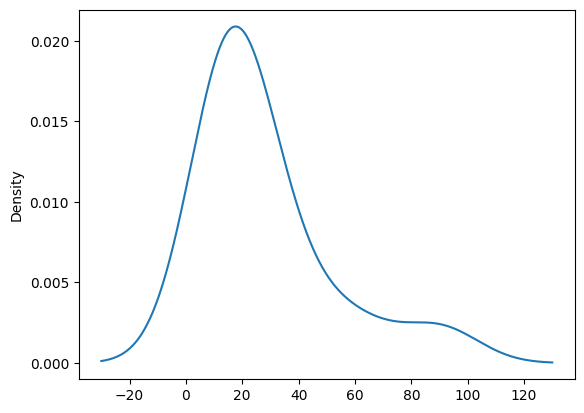

In [55]:
data = {'Age':[10,12,13,14,15,16,18,20,25,30,40,60,90]}
df = pd.DataFrame(data)
df['Age'].plot(kind='kde')

In [56]:
np.log(df['Age'])

,Age
0,2.302585
1,2.484907
2,2.564949
3,2.639057
4,2.708050
5,2.772589
6,2.890372
7,2.995732
8,3.218876
9,3.401197


In [57]:
df['Log_Age'] = np.log1p(df['Age'])

<Axes: ylabel='Density'>

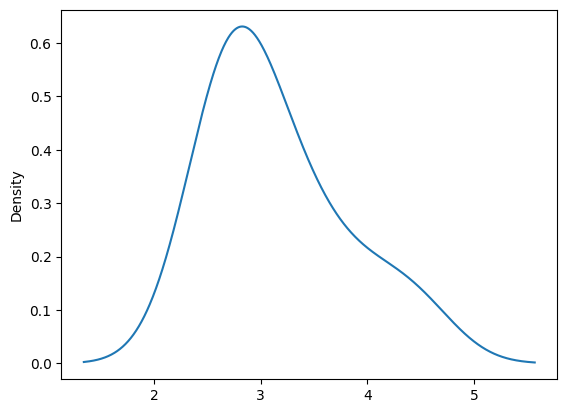

In [58]:
df['Log_Age'].plot(kind='kde')

In [59]:
data = {'Age':[10,12,13,14,15,16,18,20,25,30,40,60,90]}
df = pd.DataFrame(data)

In [60]:
df = df[df['Age']<48]

In [61]:
df

,Age
0,10
1,12
2,13
3,14
4,15
5,16
6,18
7,20
8,25
9,30


In [62]:
df = df[df['Age']>16]
df

,Age
6,18
7,20
8,25
9,30
10,40
